## Initial LLM Optimization and Stability Checks

An initial agentic optimization run was performed for both conditions: **with biological information** and **without biological information**. The current experiment budget was limited to **3 iterations** to verify that the workflow, LLM decision-making, validation, experiment logging, and final parameter selection operate as intended. A larger exploration budget will be investigated once the workflow has been further established.

### Biology-guided optimization

* **Experiments:** 3 iterations
* **Runtime:** ~87.8 seconds
* **Selected parameters:** `n_neighbors = 15`, `resolution = 1.2`, `n_pcs = 20`
* **Selected iteration:** 2
* The LLM considered both intrinsic clustering metrics and marker-gene information when proposing and selecting configurations.
* The final selection favored the configuration with the strongest overall combination of intrinsic metrics, cluster structure, and biologically coherent cell populations.

### No-biology optimization

* **Experiments:** 3 iterations
* **Runtime:** ~75.2 seconds
* **Selected parameters:** `n_neighbors = 30`, `resolution = 0.8`, `n_pcs = 20`
* **Selected iteration:** 2
* The LLM relied on intrinsic clustering metrics and cluster structure without using marker-gene information.
* The final selection favored the configuration with the strongest overall intrinsic clustering evidence and a reasonable cluster structure.

### Initial stability check

Stability analysis was performed for the selected configurations using **10 random seeds**, resulting in **45 pairwise ARI comparisons**.

| Condition  | Cluster counts across seeds | Mean ARI | Median ARI | SD ARI |   Min–Max ARI |
| ---------- | --------------------------- | -------: | ---------: | -----: | ------------: |
| Biology    | 11–12                       |   0.8278 |     0.8274 | 0.0351 | 0.7567–0.8888 |
| No biology | 9                           |   0.8756 |     0.8712 | 0.0465 | 0.7806–0.9712 |

The initial stability check indicates that both selected configurations produce reasonably consistent clustering across random seeds. The **no-biology configuration showed higher mean ARI and identical cluster counts across all seeds**, while the biology-guided configuration showed small variations between 11 and 12 clusters.

These results are **initial checks rather than final stability conclusions**, as the optimization and parameter search are currently limited in scope.

### Next steps

1. Increase the experiment budget and perform a **more extensive parameter exploration**.
2. Perform **parameter sensitivity analysis** for `n_neighbors`, `resolution`, and `n_pcs`.
3. Compare the biology and no-biology conditions across the larger set of evaluated configurations.
4. Reassess **stability** using the final/best configurations after the broader parameter exploration.
5. Continue with biological interpretation/marker analysis and final comparison once the optimization space has been sufficiently explored.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from dotenv import load_dotenv
import os

load_dotenv(override=True)


True

In [3]:
from src import data_load as dl
from src import preprocessing_pipeline as prp
from src import clustering as cl
from src import new_evaluation as ev
from src import optimization as opt
from src import visualisation as viz
from src import marker as mk
from src.graph import graph
from src.agent import cluster_node, evaluate_node, reflection_node, final_selection_node
from src.decision import (OptimizationDecision, FinalExperimentSelection,)
from src.wt_biology_prompts import (build_reflection_prompt, build_final_selection_prompt,)
from src.experiment_logger import (create_experiment_log,save_experiment_log,add_final_result,)

import scanpy as sc
import pandas as pd
from langchain_openai.chat_models import ChatOpenAI 
from IPython.display import Image, display

In [36]:
# Stability analysis

from src.stability import run_stability_analysis, calculate_pairwise_ari, calculate_cluster_jaccard
import numpy as np
from collections import defaultdict
from collections import Counter

### Create the LLM (OPENAI)

In [4]:
llm = ChatOpenAI(model="gpt-5", temperature=0,)

## Fixed Preprocessing Pipeline

In [5]:
pbmc_data = dl.load_pbmc3k()
pbmc_data = prp.run_preprocessing_pipeline(pbmc_data)

Running QC...
Running normalization...
Running PCA...
Finished preprocessing.


In [6]:
pbmc_data.var["highly_variable"].sum()

np.int64(2000)

In [7]:
pbmc_data

AnnData object with n_obs × n_vars = 2638 × 2000
    obs: 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'scaled'

## Agent State Setup
The state acts as the agent's shared memory. Technically, LangGraph simply gives every node the same shared memory. Each node:

+ reads what it needs
+ updates what changed
+ returns the updated state

In this setup, it stores the dataset, current parameters, evaluation metrics, experiment history, and optimization progress, allowing each node in the LangGraph workflow to access the information it needs and update it as the optimization proceeds.


In [8]:
experiment_log = create_experiment_log( 
    experiment_id="EXP-027", 
    dataset="PBMC3K", 
    method="agentic_biology", 
    condition="biology", 
    agent_version="v0.5-refactored", 
    change=( "Refactored the reflection and final selection workflow, " 
             "added controlled LLM decision validation, duplicate " 
             "configuration checks, and a maximum experiment budget." ), 
    reason_for_change=( "To improve the reliability and reproducibility of agentic " 
                        "parameter exploration and to ensure that invalid or repeated " 
                        "LLM-proposed configurations are rejected before clustering." ), 
)

In [9]:
state = {
    "messages": [],

    "adata": pbmc_data,

    "parameters": {
        "n_neighbors": 15,
        "resolution": 1.0,
        "n_pcs": 20,
    },

    # Experimental condition
    "condition": "biology",

    "metrics": {},

    "history": [],

    "experiment_log": experiment_log,

    "iteration": 0,

    "decision": "continue",

    "reason": "",

    "evaluated_configs": [],

    "clustering_time": 0.0,

    "evaluation_time": 0.0,

    "llm_decision_time": 0.0,

    # Final selection fields
    "selected_iteration": None,

    "best_experiment": None,

    "final_selection_reason": None,

    "final_selection_time": 0.0,
}

In [10]:
print(pbmc_data.obsm["X_pca"].shape)

(2638, 50)


### Run Agentic Optimization

The following cell executes the agentic optimization workflow using the specified initial state and saves the resulting experiment log.

The agent will iteratively:
- run clustering,
- evaluate the clustering,
- request an LLM reflection/parameter decision,
- continue until the exploration budget is reached or the LLM decides to stop,
- and finally select the preferred experiment from the completed history.


In [11]:
result = graph.invoke(state)

save_experiment_log(result["experiment_log"])


CURRENT EVALUATION
Clusters: 10
Silhouette: 0.0748
DBI: 2.6664
WC-dispersion: 374182.5000
Banfield-Raftery: 12939.8262

LLM PROMPT

You are an expert in single-cell RNA-seq clustering optimization.

Your objective is to explore clustering parameters and identify
parameter configurations that provide strong overall clustering
evidence while avoiding unnecessary over-fragmentation or
under-clustering.

The optimization should balance potential improvement against the
cost of additional experiments. Do not continue exploring merely for
the sake of using the available experiment budget.

BIOLOGY-INFORMED EXPERIMENTAL CONDITION:

This is the biology-informed experimental condition.

* Use intrinsic clustering metrics, cluster-structure information,
  and biological evidence provided in the prompt when making
  optimization decisions.

* Biological evidence may be used to assess whether clusters appear
  biologically coherent, whether potentially distinct populations may
  have been merged,

PosixPath('experiments/EXP-027.json')

In [12]:
# print(graph.get_graph().draw_mermaid())

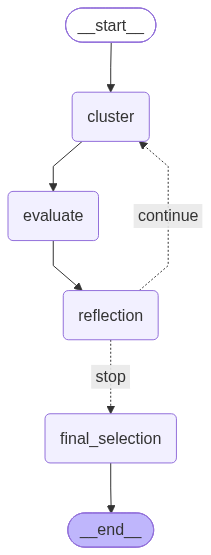

In [13]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
print("Decision:", result["decision"])
print("Reason:", result["reason"])

Decision: stop
Reason: Maximum number of experiments (3) reached.


In [15]:
state.keys()

dict_keys(['messages', 'adata', 'parameters', 'condition', 'metrics', 'history', 'experiment_log', 'iteration', 'decision', 'reason', 'evaluated_configs', 'clustering_time', 'evaluation_time', 'llm_decision_time', 'selected_iteration', 'best_experiment', 'final_selection_reason', 'final_selection_time'])

In [16]:
# print(type(decision))

In [ ]:
for experiment in result["history"]:
    print("\nIteration:", experiment["iteration"])
    print("Parameters:", experiment["parameters"])
    print("Metrics:", experiment["metrics"])

In [18]:
# print(decision)

In [26]:
best_experiment = result["history"][2]

best_params = best_experiment["parameters"]

print(best_params)

{'n_neighbors': 15, 'resolution': 1.2, 'n_pcs': 20}


In [27]:
pbmc_data_best = cl.run_clustering(
    pbmc_data.copy(),
    n_neighbors=best_params["n_neighbors"],
    resolution=best_params["resolution"],
    n_pcs=best_params["n_pcs"],)

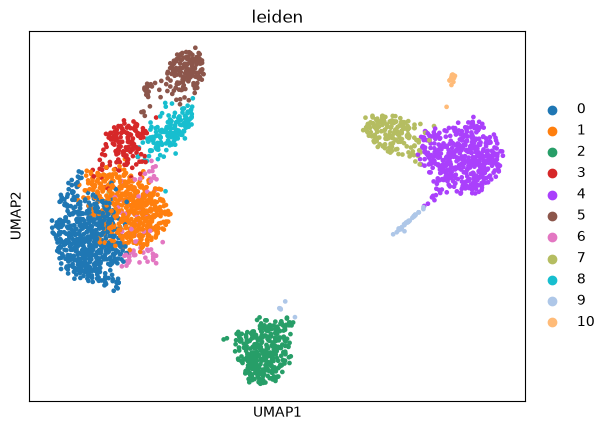

In [28]:
viz.plot_umap(pbmc_data_best, color="leiden")

In [29]:
ev.get_cluster_summary(pbmc_data_best)

{'0': 576,
 '1': 511,
 '2': 342,
 '3': 140,
 '4': 469,
 '5': 165,
 '6': 73,
 '7': 169,
 '8': 148,
 '9': 31,
 '10': 14}

In [ ]:
result["metrics"]["marker_genes"]

## Sensitivity Analysis

Initial robustness check

In [32]:
stability_biology = run_stability_analysis(
    pbmc_data,
    n_neighbors=15,
    resolution=1.2,
    n_pcs=20,
    seeds=range(10),
)

print("Cluster counts:", stability_biology["cluster_counts"])

Cluster counts: [11, 12, 11, 11, 12, 11, 11, 12, 11, 12]


In [34]:
cluster_count_frequency = Counter(stability_biology["cluster_counts"])

print("Cluster count frequency:")
for k, count in sorted(cluster_count_frequency.items()):
    print(f"K={k}: {count}/10 runs")

Cluster count frequency:
K=11: 6/10 runs
K=12: 4/10 runs


In [35]:
ari_scores = calculate_pairwise_ari(stability_biology["assignments"])

print("Number of pairwise comparisons:", len(ari_scores))
print("Mean ARI:", sum(ari_scores) / len(ari_scores), end="\n")
print("-----------------")
print("Stability summary")
print("-----------------")
print(f"Mean ARI:   {np.mean(ari_scores):.4f}",  end='\n')
print(f"Median ARI: {np.median(ari_scores):.4f}",  end='\n')
print(f"SD ARI:     {np.std(ari_scores):.4f}",  end='\n')
print(f"Min ARI:    {np.min(ari_scores):.4f}",  end='\n')
print(f"Max ARI:    {np.max(ari_scores):.4f}")

Number of pairwise comparisons: 45
Mean ARI: 0.8278334936468909
-----------------
Stability summary
-----------------
Mean ARI:   0.8278
Median ARI: 0.8274
SD ARI:     0.0351
Min ARI:    0.7567
Max ARI:    0.8888
